In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

# Default: local Ollama smollm2:360m-instruct-fp16 -- the same small local
# model used throughout this repo's demonstration suite. No API key, runs
# offline once pulled. Make sure `ollama serve` is running and the model is
# pulled:
#   ollama pull smollm2:360m-instruct-fp16
MODEL_NAME   = "smollm2:360m-instruct-fp16"
MODEL_FAMILY = "ollama"

# Alternative: Groq-hosted gpt-oss-120b. Uncomment to use, and make sure
# GROQ_API_KEY is set in your .env. psychscanner loads it automatically.
# MODEL_NAME   = "openai/gpt-oss-120b"
# MODEL_FAMILY = "groq"

from langchain.chat_models import init_chat_model

llm = init_chat_model(model=MODEL_NAME, model_provider=MODEL_FAMILY, temperature=0)
llm.invoke("what's your name")

AIMessage(content="I don't have a personal name, but I'm often referred to as a friendly AI assistant! How can I help you today?", additional_kwargs={}, response_metadata={'model': 'smollm2:360m-instruct-fp16'})

In [ ]:
from psychscanner import ExpCard, ExpCardInit, ScannerModel

In [ ]:
from pathlib import Path
import shutil

TASK_FILE = Path.cwd() / 'tasks' / 'nback_sweetpea_n2.tcard.psyscan'
RUN_DIR   = Path.cwd() / '_nback_tutorial_runs'
# if RUN_DIR.exists():
#     shutil.rmtree(RUN_DIR)

print(f'{TASK_FILE.name}  (exists={TASK_FILE.exists()})')
# One task card covers every memory/chain_type variant below -- unlike the
# old Reality Monitoring example this quickstart used to run, n-back's items
# are single-stimulus-per-trial, so ExpCardInit.memory/.chain_type alone
# determine the variant, not a different task file per variant.

nback_sweetpea_n2.tcard.psyscan  (exists=True)


In [ ]:
def make_card(variant, *, memory, chain_type):
    card = ExpCardInit()
    card.proj_dir      = RUN_DIR / variant
    card.projectname   = variant
    card.model         = MODEL_NAME
    card.family        = MODEL_FAMILY
    card.parameters    = {'temperature': 0}
    card.task_file     = TASK_FILE
    card.parser        = '0'   # free text ('match'/'no-match'), no structured schema
    card.cogtype       = 'no'
    card.nsim          = 1
    card.tunnel_status = '0'
    card.memory        = memory
    card.chain_type    = chain_type
    return card


def decode(pred_resp):
    return pred_resp.content if hasattr(pred_resp, 'content') else str(pred_resp)


def show_trials(trials, label=''):
    if label:
        print(f'--- {label} ---')
    print(f'  {"trcode":24}  {"corrAns":9} response')
    print(f'  {"-"*24}  {"-"*9} {"-"*30}')
    for t in trials:
        resp = decode(t['pred_resp'])
        print(f"  {t['trcode']:24}  {t['corrAns']:9} {resp.strip()[:30]!r}")

In [ ]:
card_v1  = make_card('singleturn', memory='SingleTurn', chain_type='item')
exp_v1   = ExpCard(card_v1)
scanner_v1 = ScannerModel(expcard=exp_v1)
trials_v1  = scanner_v1.run()[0]
print()
show_trials(trials_v1, label='V1 — singleturn / item / no memory')


--- V1 — singleturn / item / no memory ---
  trcode                    corrAns   response
  ------------------------  --------- ------------------------------
  nback_sweetpea_n2_01      match     '"No-match"'
  nback_sweetpea_n2_02      no-match  '"No-match"'
  nback_sweetpea_n2_03      no-match  '"No-match"'
  nback_sweetpea_n2_04      no-match  '"No-match"'
  nback_sweetpea_n2_05      match     '"No-match"'
  nback_sweetpea_n2_06      no-match  '"No-match"'
  nback_sweetpea_n2_07      match     '"No-match"'
  nback_sweetpea_n2_08      no-match  '"Current letter: C"'
  nback_sweetpea_n2_09      no-match  '"Current letter: C"'
  nback_sweetpea_n2_10      no-match  '"No-match"'
  nback_sweetpea_n2_11      no-match  '"No-match"'
  nback_sweetpea_n2_12      no-match  '"No-match"'
  nback_sweetpea_n2_13      no-match  '"Current letter: C"'
  nback_sweetpea_n2_14      no-match  '"Current letter: C"'
  nback_sweetpea_n2_15      no-match  '"No-match"'
  nback_sweetpea_n2_16      match     '

## Trial-chain variant

Same task, real conversational memory across trials instead of none:
`chain_type='trial'`, `memory='Convo'` — the n-back generator's own design
note explains why this uses psychscanner's real trial-chain memory rather
than a hand-baked history string in the prompt (see
`examples/tasks/generators/generate_nback_sweetpea.py`). `parser='0'` — the
card has no structured schema; grading below is a plain substring match
against `corrAns`.

In [ ]:
card_tc  = make_card('trialchain', memory='Convo', chain_type='trial')
exp_tc   = ExpCard(card_tc)
scanner_tc = ScannerModel(expcard=exp_tc)
trials_tc  = scanner_tc.run()[0]
print()
show_trials(trials_tc, label='Trial-chain — trial / Convo memory')

same_as_v1 = [decode(a['pred_resp']) for a in trials_v1] == [decode(b['pred_resp']) for b in trials_tc]
print(f'\nIdentical raw responses to Single-Turn? {same_as_v1}')


--- Trial-chain — trial / Convo memory ---
  trcode                    corrAns   response
  ------------------------  --------- ------------------------------
  nback_sweetpea_n2_01      match     '"No-match"'
  nback_sweetpea_n2_02      no-match  '"No-match"'
  nback_sweetpea_n2_03      no-match  '"No-match"'
  nback_sweetpea_n2_04      no-match  '"No-match"'
  nback_sweetpea_n2_05      match     '"No-match"'
  nback_sweetpea_n2_06      no-match  '"No-match"'
  nback_sweetpea_n2_07      match     '"No-match"'
  nback_sweetpea_n2_08      no-match  '"Current letter: C"'
  nback_sweetpea_n2_09      no-match  '"Current letter: C"'
  nback_sweetpea_n2_10      no-match  '"No-match"'
  nback_sweetpea_n2_11      no-match  '"No-match"'
  nback_sweetpea_n2_12      no-match  '"No-match"'
  nback_sweetpea_n2_13      no-match  '"Current letter: C"'
  nback_sweetpea_n2_14      no-match  '"Current letter: C"'
  nback_sweetpea_n2_15      no-match  '"No-match"'
  nback_sweetpea_n2_16      match     '

## Data extraction

Export both runs to CSV, concatenate, then visualise the raw responses.

In [ ]:
from psychscanner import to_csv

OUT = RUN_DIR / 'csv'
OUT.mkdir(parents=True, exist_ok=True)

df_st = to_csv(scanner_v1, path=OUT / 'nback_singleturn.csv')
df_tc = to_csv(scanner_tc, path=OUT / 'nback_trialchain.csv')

df_all = to_csv([scanner_v1, scanner_tc],
                path=OUT / 'nback_combined.csv',
                combined=True)

print(f'Single-Turn  rows: {df_st.shape}')
print(f'Trial-Chain  rows: {df_tc.shape}')
print(f'Combined     rows: {df_all.shape}')
df_all.select(['memory', 'trcode', 'pred_resp_raw']).head(10)

Single-Turn  rows: (22, 19)
Trial-Chain  rows: (22, 19)
Combined     rows: (44, 19)


shape: (10, 3)
┌────────────┬──────────────────────┬─────────────────────┐
│ memory     ┆ trcode               ┆ pred_resp_raw       │
│ ---        ┆ ---                  ┆ ---                 │
│ str        ┆ str                  ┆ str                 │
╞════════════╪══════════════════════╪═════════════════════╡
│ SingleTurn ┆ nback_sweetpea_n2_01 ┆ "No-match"          │
│ SingleTurn ┆ nback_sweetpea_n2_02 ┆ "No-match"          │
│ SingleTurn ┆ nback_sweetpea_n2_03 ┆ "No-match"          │
│ SingleTurn ┆ nback_sweetpea_n2_04 ┆ "No-match"          │
│ SingleTurn ┆ nback_sweetpea_n2_05 ┆ "No-match"          │
│ SingleTurn ┆ nback_sweetpea_n2_06 ┆ "No-match"          │
│ SingleTurn ┆ nback_sweetpea_n2_07 ┆ "No-match"          │
│ SingleTurn ┆ nback_sweetpea_n2_08 ┆ "Current letter: C" │
│ SingleTurn ┆ nback_sweetpea_n2_09 ┆ "Current letter: C" │
│ SingleTurn ┆ nback_sweetpea_n2_10 ┆ "No-match"          │
└────────────┴──────────────────────┴─────────────────────┘

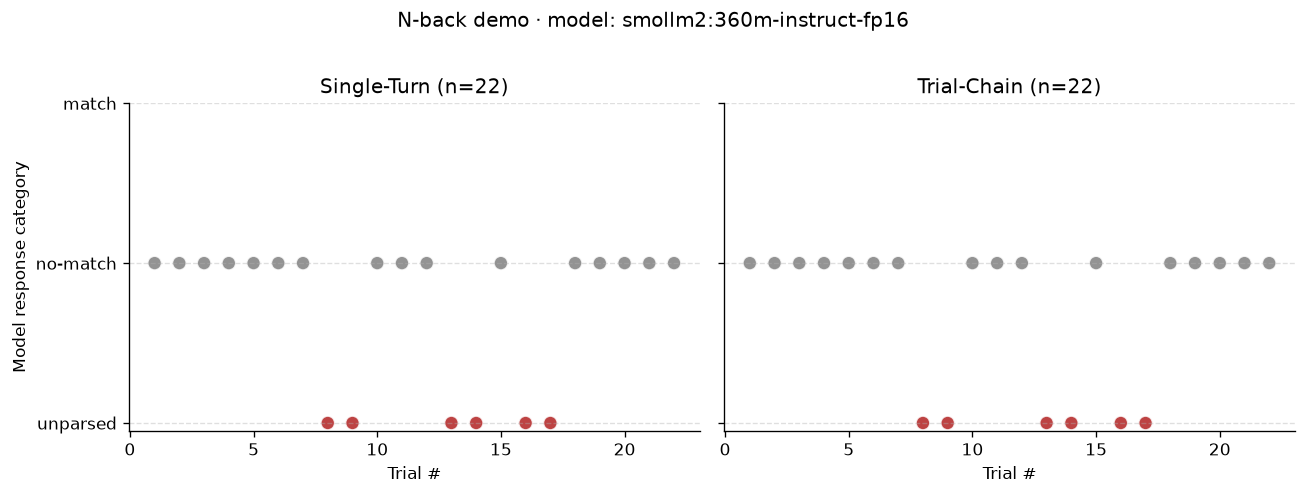

figure → _nback_tutorial_runs/csv/nback_demo_figure.png


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_judgments(csv_path):
    df = pd.read_csv(csv_path)
    def cat(s):
        s = str(s).lower()
        if 'no-match' in s or 'no match' in s:
            return 'no-match'
        if 'match' in s:
            return 'match'
        return 'unparsed'
    df['judged'] = df['pred_resp_raw'].apply(cat)
    return df

df_st_j = load_judgments(OUT / 'nback_singleturn.csv')
df_tc_j = load_judgments(OUT / 'nback_trialchain.csv')

_CAT_Y = {'match': 2, 'no-match': 1, 'unparsed': 0}
_CAT_COLOR = {'match': 'steelblue', 'no-match': 'gray', 'unparsed': 'firebrick'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, df, title in [(ax1, df_st_j, 'Single-Turn'), (ax2, df_tc_j, 'Trial-Chain')]:
    x = np.arange(1, len(df) + 1)
    y = df['judged'].map(_CAT_Y).values
    colors = df['judged'].map(_CAT_COLOR).values
    ax.scatter(x, y, c=colors, s=70, alpha=0.85, edgecolors='white')
    ax.set_title(f'{title} (n={len(df)})')
    ax.set_xlabel('Trial #')
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['unparsed', 'no-match', 'match'])
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)
ax1.set_ylabel('Model response category')
fig.suptitle(f'N-back demo · model: {MODEL_NAME}', y=1.02)
plt.tight_layout()
fig.savefig(OUT / 'nback_demo_figure.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'figure → {OUT / "nback_demo_figure.png"}')

## N-back accuracy

2-back accuracy for the two runs above (default `temperature=0`, `nsim=1`, no
feedback) — the model's match/no-match judgment compared against each
trial's `corrAns`. See [05_nback_task.ipynb](05_nback_task.ipynb) for the
same task run across all four memory/feedback configurations, including
what happens when corrective feedback is added.

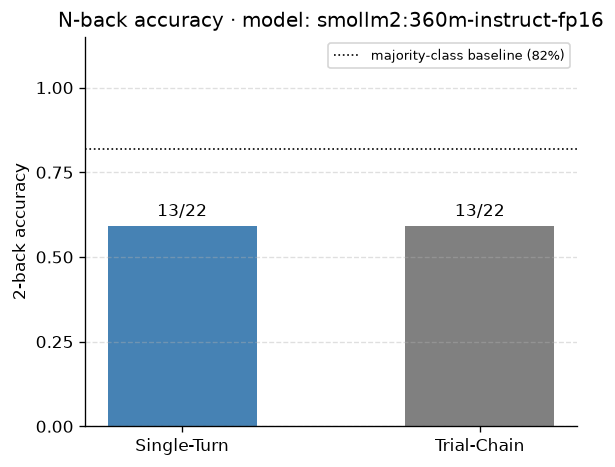

figure → _nback_tutorial_runs/csv/nback_accuracy_figure.png
Single-Turn  accuracy: 13/22 = 59%
Trial-Chain  accuracy: 13/22 = 59%


In [ ]:
import json as _json

_task = _json.loads(TASK_FILE.read_text())
_CORR_ANS = {trcode: trials[0]['corrAns'] for trcode, trials in _task['items'].items()}

def load_accuracy(csv_path):
    df = pd.read_csv(csv_path)
    def cat(s):
        s = str(s).lower()
        if 'no-match' in s or 'no match' in s:
            return 'no-match'
        if 'match' in s:
            return 'match'
        return None
    df['judged'] = df['pred_resp_raw'].apply(cat)
    df['corrAns'] = df['trcode'].map(_CORR_ANS)
    correct = (df['judged'] == df['corrAns']).sum()
    return correct, len(df)

correct_st, n_st = load_accuracy(OUT / 'nback_singleturn.csv')
correct_tc, n_tc = load_accuracy(OUT / 'nback_trialchain.csv')

fig, ax = plt.subplots(figsize=(5, 4))
labels = ['Single-Turn', 'Trial-Chain']
accs = [correct_st / n_st, correct_tc / n_tc]
bars = ax.bar(labels, accs, color=['steelblue', 'gray'], width=0.5)
for bar, acc, correct, n in zip(bars, accs, [correct_st, correct_tc], [n_st, n_tc]):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.03, f'{correct}/{n}', ha='center', fontsize=10)
ax.axhline(18/22, color='black', linestyle=':', linewidth=1, label='majority-class baseline (82%)')
ax.set_ylim(0, 1.15); ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_ylabel('2-back accuracy')
ax.set_title(f'N-back accuracy · model: {MODEL_NAME}')
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(OUT / 'nback_accuracy_figure.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'figure → {OUT / "nback_accuracy_figure.png"}')
print(f'Single-Turn  accuracy: {correct_st}/{n_st} = {correct_st/n_st:.0%}')
print(f'Trial-Chain  accuracy: {correct_tc}/{n_tc} = {correct_tc/n_tc:.0%}')

## Verify install by running the README Quick Start test directly

This calls the test function from `tests/test_readme_quickstart.py` without
invoking pytest — so unrelated tests (like `test_cli.py`) are never touched.


In [10]:
import sys, tempfile, urllib.request, urllib.error
from pathlib import Path

# Make the package's tests/ importable (it has __init__.py, so it works as a module)
PKG_ROOT = Path.cwd().parent
if str(PKG_ROOT) not in sys.path:
    sys.path.insert(0, str(PKG_ROOT))

from tests.test_readme_quickstart import (
    test_readme_quickstart_smoke,
    test_readme_quickstart_live_ollama,
)

# 1. Smoke test: validates ExpCard, default task, parser registry — no API calls
with tempfile.TemporaryDirectory() as tmp:
    test_readme_quickstart_smoke(Path(tmp))
print("PASS — README Quick Start smoke test")

# 2. Live Ollama test: skipped if Ollama isn't reachable on localhost
def _ollama_up(timeout=2.0):
    try:
        with urllib.request.urlopen("http://localhost:11434/api/tags", timeout=timeout) as r:
            return r.status == 200
    except (urllib.error.URLError, TimeoutError, ConnectionError):
        return False

if _ollama_up():
    try:
        with tempfile.TemporaryDirectory() as tmp:
            test_readme_quickstart_live_ollama(Path(tmp))
        print("PASS — README Quick Start live Ollama test")
    except Exception as e:
        print(f"SKIPPED live test: {type(e).__name__}: {str(e)[:140]}")
else:
    print("SKIPPED live test: Ollama not reachable on localhost:11434")


----<PROJECT AND DATA ROOT DIRECTORY>----


	Project root dir: /var/folders/2f/1mng0xs503787mwn287f9_d00000gn/T/tmplbzcuehi


	Simulation data root dir: /var/folders/2f/1mng0xs503787mwn287f9_d00000gn/T/tmplbzcuehi/readme_quickstart_test/vviq16/ollama_smollm2:360m-instruct-fp16_SingleTurn


----<>----


--<api key>-- warning: OLLAMA_API_KEY not set; proceeding without explicit api_key for family 'ollama'


...

16it [00:18,  1.14s/it]


2026-08-03 17:58:58.489 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 0


2026-08-03 17:58:58.493 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END


Saved 16 rows → /var/folders/2f/1mng0xs503787mwn287f9_d00000gn/T/tmp_k1fntpq/readme_quickstart_test_vviq16_smollm2-360m-instruct-fp16_SingleTurn_20260803_175858.csv
PASS — README Quick Start live Ollama test


## VVIQ-16 mini study (lifted from the unit test)

This block runs the same VVIQ-16 task validated by
`tests/test_readme_quickstart.py::test_readme_quickstart_live_ollama`,
then adds a **Convo** condition for comparison and reproduces the
`09_vviq16_study.ipynb` plot at small scale.


In [11]:
# Mirror of test_readme_quickstart_live_ollama (n=2 instead of 1)
from psychscanner import ExpCardInit, ExpCard, ScannerModel, to_csv
from psychscanner.parsers import DefaultLiteralVivid15

VVIQ_DIR = RUN_DIR / "vviq16"
VVIQ_DIR.mkdir(parents=True, exist_ok=True)
NSIM = 2  # small for a quick local run; bump up for real studies

def vviq_card(memory: str):
    return ExpCardInit(
        model       = MODEL_NAME,
        family      = MODEL_FAMILY,
        parameters  = {"temperature": 0},
        projectname = "vviq16_quickstart",
        proj_dir    = VVIQ_DIR,
        cogtype     = "no",
        nsim        = NSIM,
        memory      = memory,
        parser      = DefaultLiteralVivid15,
    )

scanner_st = ScannerModel(expcard=ExpCard(vviq_card("SingleTurn")))
results_st = scanner_st.run()
print(f"SingleTurn: {len(results_st)} simulations × {len(results_st[0])} trials")


----<PROJECT AND DATA ROOT DIRECTORY>----


	Project root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16


	Simulation data root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_quickstart/vviq16/ollama_smollm2:360m-instruct-fp16_SingleTurn


----<>----


--<api key>-- warning: OLLAMA_API_KEY not set; proceeding without explicit api_key for family 'ollama'


...

16it [00:23,  1.49s/it]


2026-08-03 17:59:39.613 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 1


2026-08-03 17:59:39.618 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END


SingleTurn: 2 simulations × 16 trials


In [12]:
scanner_cv = ScannerModel(expcard=ExpCard(vviq_card("Convo")))
results_cv = scanner_cv.run()
print(f"Convo:      {len(results_cv)} simulations × {len(results_cv[0])} trials")


----<PROJECT AND DATA ROOT DIRECTORY>----


	Project root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16


	Simulation data root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_quickstart/vviq16/ollama_smollm2:360m-instruct-fp16_Convo


----<>----


--<api key>-- warning: OLLAMA_API_KEY not set; proceeding without explicit api_key for family 'ollama'


...

16it [00:33,  2.07s/it]


2026-08-03 18:00:44.785 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 1


2026-08-03 18:00:44.791 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END


Convo:      2 simulations × 16 trials


In [13]:
# Export per-condition + combined CSVs
df_st = to_csv(scanner_st, path=VVIQ_DIR / "vviq16_singleturn.csv")
df_cv = to_csv(scanner_cv, path=VVIQ_DIR / "vviq16_convo.csv")
df_all = to_csv([scanner_st, scanner_cv],
                path=VVIQ_DIR / "vviq16_combined.csv",
                combined=True)
print(f"SingleTurn rows: {df_st.shape}")
print(f"Convo      rows: {df_cv.shape}")
print(f"Combined   rows: {df_all.shape}")
df_all.select(["memory", "trcode", "trial_idx", "resp_Vividness"]).head(6)


Saved 32 rows → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_singleturn.csv
Saved 32 rows → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_convo.csv
Saved 64 rows from 2 source(s) → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_combined.csv
SingleTurn rows: (32, 20)
Convo      rows: (32, 20)
Combined   rows: (64, 20)


memory,trcode,trial_idx,resp_Vividness
str,str,i64,i64
"""SingleTurn""","""S1_1""",0,4
"""SingleTurn""","""S1_2""",1,4
"""SingleTurn""","""S1_3""",2,4
"""SingleTurn""","""S1_4""",3,4
"""SingleTurn""","""S2_1""",4,4
"""SingleTurn""","""S2_2""",5,4


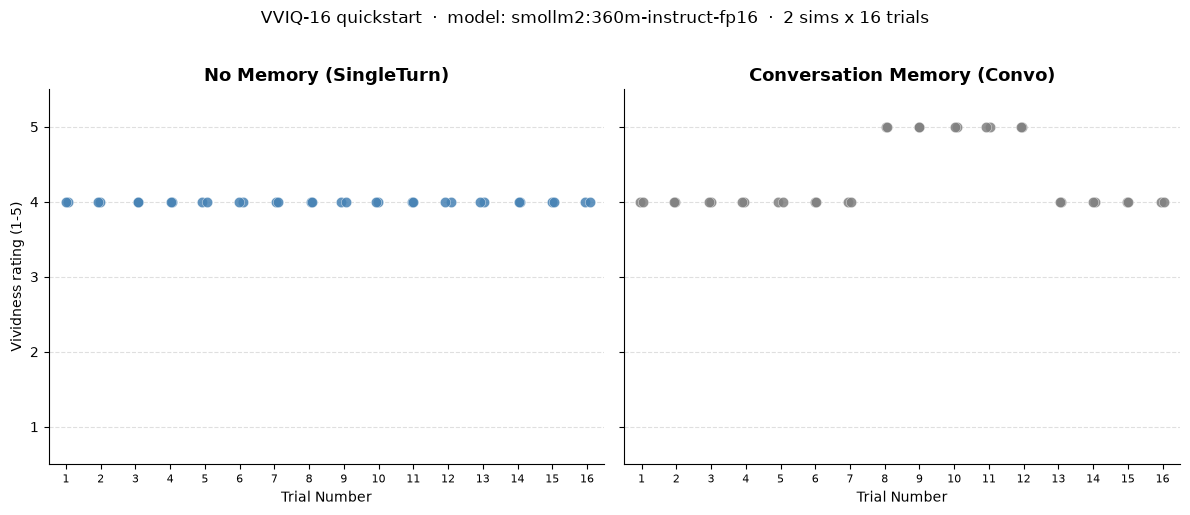

figure -> /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_rm_tutorial_runs/vviq16/vviq16_figure.png
mean Vividness  SingleTurn=4.00  Convo=4.31


In [14]:
# Reproduce the 09_vviq16_study.ipynb scatter (small-n version)
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt

_VIV_RE = re.compile(r"Vividness[^0-9]*(\d+)")

def load_vividness(csv_path):
    df = pd.read_csv(csv_path)
    df["Vividness"] = df["pred_resp_raw"].apply(
        lambda s: int(_VIV_RE.search(str(s)).group(1)) if _VIV_RE.search(str(s)) else None
    )
    return (df["trial_idx"] + 1).values.astype(float), df["Vividness"].values.astype(float)

x_st, y_st = load_vividness(VVIQ_DIR / "vviq16_singleturn.csv")
x_cv, y_cv = load_vividness(VVIQ_DIR / "vviq16_convo.csv")

rng = np.random.default_rng(42)
def jitter(x, s=0.10): return x + rng.uniform(-s, s, size=len(x))

fig, (ax_st, ax_cv) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
ax_st.scatter(jitter(x_st), y_st, color="steelblue", s=55, alpha=0.85,
              linewidths=0.3, edgecolors="white", zorder=3)
ax_st.set_title("No Memory (SingleTurn)", fontsize=13, fontweight="bold")
ax_st.set_xlabel("Trial Number"); ax_st.set_ylabel("Vividness rating (1-5)")

ax_cv.scatter(jitter(x_cv), y_cv, color="gray", s=55, alpha=0.85,
              linewidths=0.3, edgecolors="white", zorder=3)
ax_cv.set_title("Conversation Memory (Convo)", fontsize=13, fontweight="bold")
ax_cv.set_xlabel("Trial Number")

for ax in (ax_st, ax_cv):
    ax.set_xlim(0.5, 16.5); ax.set_xticks(range(1, 17))
    ax.set_xticklabels(range(1, 17), fontsize=8)
    ax.set_ylim(0.5, 5.5); ax.set_yticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"VVIQ-16 quickstart  ·  model: {MODEL_NAME}  ·  {NSIM} sims x 16 trials",
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(VVIQ_DIR / "vviq16_figure.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"figure -> {VVIQ_DIR / 'vviq16_figure.png'}")
m_st = float(np.nanmean(y_st)) if y_st.size else float("nan")
m_cv = float(np.nanmean(y_cv)) if y_cv.size else float("nan")
print(f"mean Vividness  SingleTurn={m_st:.2f}  Convo={m_cv:.2f}")


---
## Further reading

From the psychscanner team, on the two tasks run above:

1. **["Reality Monitoring in Large Language Models: Self-Knowledge That Transforms with Conversation Memory"](https://arxiv.org/abs/2607.23927)** (Ranjan, Sokratous & Odegaard, 2026) — the paper this repo''s Single-Turn vs Trial-Chain memory-condition manipulation (run above on the n-back task) originally comes from, there tested on a source-monitoring task across six LLMs.
2. **["Psychological Imagination Networks Show Cross-Population Centrality and Clustering Alignment in Humans That Large Language Models Fail to Replicate"](https://arxiv.org/abs/2510.04391)** (Ranjan & Odegaard, 2025) — network-science analysis of VVIQ ratings across humans and LLMs, directly relevant to the VVIQ-16 mini study run above.

Background on the field:

3. **["Large Language Models as Psychological Simulators: A Methodological Guide"](https://arxiv.org/abs/2506.16702)** (Lin, 2025) — a methodological framework for exactly what this notebook demonstrates: LLMs standing in as simulated participants and computational models of cognition.
4. **["Can Large Language Models Replace Human Subjects? A Large-Scale Replication of Scenario-Based Experiments in Psychology and Management"](https://arxiv.org/abs/2409.00128)** (Cui, Li & Zhou, 2024) — replicates 156 published psychology/management experiments with LLM participants, at a scale far beyond this quickstart's single-trial demo.